In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from google.colab import drive
# Load data
drive.mount("/content/drive")
df = pd.read_excel("/content/drive/MyDrive/Folds5x2_pp.xlsx")
dataset = pd.read_excel('/content/drive/MyDrive/Folds5x2_pp.xlsx')
# Assuming the user wants to work with the 'dataset' DataFrame
dataset.columns = ['AT', 'V', 'AP', 'RH', 'PE']  # Suhu, Tekanan, Kelembapan, Bakum, Daya

# Normalisasi data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(dataset) # Changed data to dataset

# Pisahkan fitur dan target
X = scaled_data[:, :-1]  # 4 fitur input
y = scaled_data[:, -1]   # output daya

# Reshape data untuk LSTM (samples, timesteps, features)
# Asumsi kita menggunakan data jam-an dengan look_back = 1 (data sebelumnya)
look_back = 1
X_lstm = []
y_lstm = []

for i in range(look_back, len(X)):
    X_lstm.append(X[i-look_back:i, :])
    y_lstm.append(y[i])

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# Split data train dan test
X_train, X_test, y_train, y_test = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# Membangun model LSTM
from tensorflow.keras.models import Sequential # Import Sequential model
from tensorflow.keras.layers import LSTM, Dense # Import LSTM and Dense layers
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(X_lstm.shape[1], X_lstm.shape[2])))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mse')

# --- MENGUKUR WAKTU TRAINING LSTM (Kode Baru) ---
print("Memulai pelatihan model LSTM...")
start_train_lstm = time.time()

# Melatih model
history_lstm = model_lstm.fit(X_train, y_train,
                            epochs=50,
                            batch_size=32,
                            validation_data=(X_test, y_test),
                            verbose=1)
end_train_lstm = time.time()
training_time_lstm = end_train_lstm - start_train_lstm

Memulai pelatihan model LSTM...
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1204 - val_loss: 0.0532
Epoch 2/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0540 - val_loss: 0.0526
Epoch 3/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0525 - val_loss: 0.0522
Epoch 4/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0531 - val_loss: 0.0518
Epoch 5/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0513 - val_loss: 0.0518
Epoch 6/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0513 - val_loss: 0.0519
Epoch 7/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0512 - val_loss: 0.0519
Epoch 8/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0517 - val_loss: 0.0516
Epoch 9/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0516 - val_loss: 0.0515
Epoch 10/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0512 - val_loss: 0.0518
Epoch 11/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0507 - val_loss: 0.0516
Epoch 12/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Waktu Prediksi LSTM: 0.6918 detik
RMSE LSTM: 0.22692149863356018


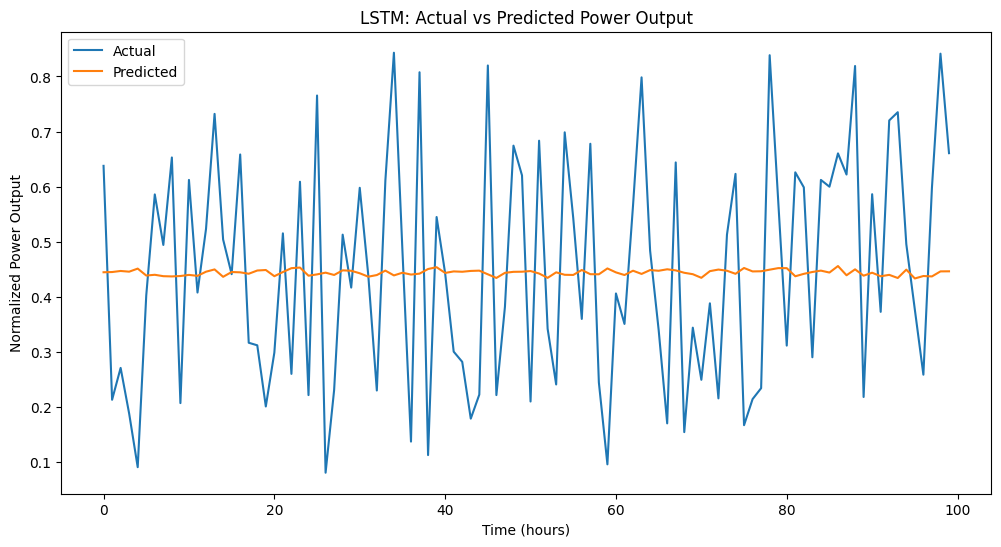

In [25]:
# --- MENGUKUR WAKTU PREDIKSI LSTM ---
start_pred_lstm = time.time()

# Prediksi
y_pred_lstm = model_lstm.predict(X_test)

end_pred_lstm = time.time()
prediction_time_lstm = end_pred_lstm - start_pred_lstm
print(f"Waktu Prediksi LSTM: {prediction_time_lstm:.4f} detik")

# Hitung RMSE
from sklearn.metrics import mean_squared_error
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
print(f"RMSE LSTM: {rmse_lstm}")

# Visualisasi hasil
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test[:100], label='Actual')
plt.plot(y_pred_lstm[:100], label='Predicted')
plt.title('LSTM: Actual vs Predicted Power Output')
plt.xlabel('Time (hours)')
plt.ylabel('Normalized Power Output')
plt.legend()
plt.show()

In [28]:
# Tampilkan hasil waktu
print(f"\nWaktu Training LSTM: {training_time_lstm:.4f} detik")
print(f"Waktu Prediksi LSTM: {prediction_time_lstm:.4f} detik")



Waktu Training LSTM: 64.7328 detik
Waktu Prediksi LSTM: 0.6918 detik



Memulai pelatihan model GRU...
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1061 - val_loss: 0.0528
Epoch 2/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0518 - val_loss: 0.0522
Epoch 3/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0521 - val_loss: 0.0525
Epoch 4/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0522 - val_loss: 0.0520
Epoch 5/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0516 - val_loss: 0.0516
Epoch 6/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0515 - val_loss: 0.0516
Epoch 7/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0518 - val_loss: 0.0516
Epoch 8/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0516 - val_loss: 0.0514
Epoch 9/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0506 - val_loss: 0.0517
Epoch 10/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0511 - val_loss: 0.0524
Epoch 11/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0512 - val_loss: 0.0514
Epoch 12/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.

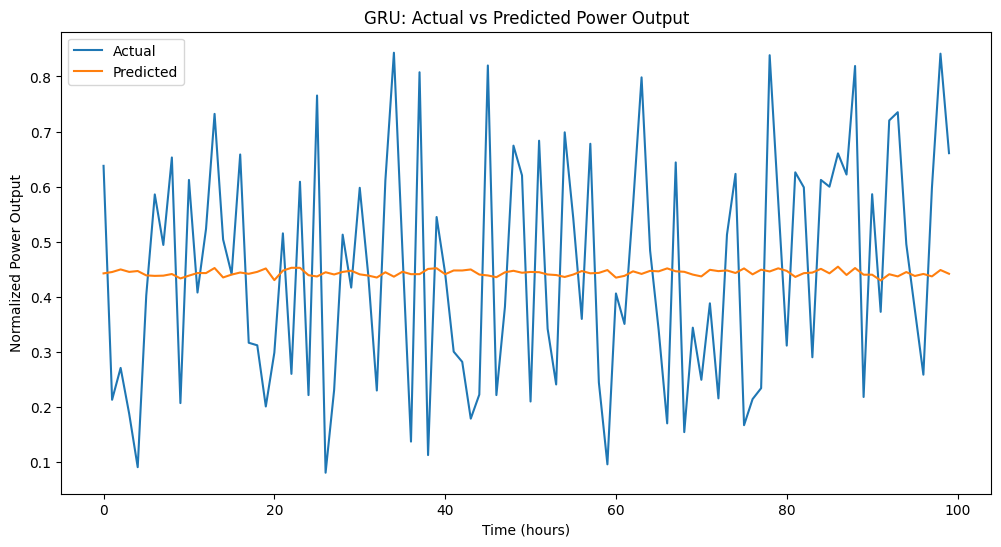

In [26]:
from tensorflow.keras.layers import GRU

# Membangun model GRU
model_gru = Sequential()
model_gru.add(GRU(50, activation='relu', input_shape=(X_lstm.shape[1], X_lstm.shape[2])))
model_gru.add(Dense(1))
model_gru.compile(optimizer='adam', loss='mse')

# --- MENGUKUR WAKTU TRAINING GRU (Kode Baru) ---
print("\nMemulai pelatihan model GRU...")
start_train_gru = time.time()

# Melatih model
history_gru = model_gru.fit(X_train, y_train,
                          epochs=50,
                          batch_size=32,
                          validation_data=(X_test, y_test),
                          verbose=1)
end_train_gru = time.time()
training_time_gru = end_train_gru - start_train_gru
# --- Akhir Pengukuran Waktu Training ---

# --- MENGUKUR WAKTU PREDIKSI GRU ---
start_pred_gru = time.time()

# Evaluasi
y_pred_gru = model_gru.predict(X_test)

end_pred_gru = time.time()
prediction_time_gru = end_pred_gru - start_pred_gru
print(f"Waktu Prediksi GRU: {prediction_time_gru:.4f} detik")
# Evaluasi
y_pred_gru = model_gru.predict(X_test)
rmse_gru = np.sqrt(mean_squared_error(y_test, y_pred_gru))
print(f"RMSE GRU: {rmse_gru}")

# Visualisasi
plt.figure(figsize=(12, 6))
plt.plot(y_test[:100], label='Actual')
plt.plot(y_pred_gru[:100], label='Predicted')
plt.title('GRU: Actual vs Predicted Power Output')
plt.xlabel('Time (hours)')
plt.ylabel('Normalized Power Output')
plt.legend()
plt.show()

In [27]:
# Tampilkan hasil waktu
print(f"\nWaktu Training GRU: {training_time_gru:.4f} detik")
print(f"Waktu Prediksi GRU: {prediction_time_gru:.4f} detik")


Waktu Training GRU: 66.6013 detik
Waktu Prediksi GRU: 0.6890 detik


In [ ]:
# Model LSTM dalam
model_deep_lstm = Sequential()
model_deep_lstm.add(LSTM(100, activation='relu', input_shape=(look_back, X.shape[1]), return_sequences=True))
model_deep_lstm.add(LSTM(50, activation='relu'))
model_deep_lstm.add(Dense(1))
model_deep_lstm.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Model dengan dropout
from tensorflow.keras.layers import Dropout # Import the Dropout layer
model_lstm_dropout = Sequential()
model_lstm_dropout.add(LSTM(100, activation='relu', input_shape=(look_back, X.shape[1])))
model_lstm_dropout.add(Dropout(0.2))
model_lstm_dropout.add(Dense(1))
model_lstm_dropout.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
from tensorflow.keras.layers import GRU, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Install Keras Tuner if you haven't already
!pip install keras-tuner -q

# Import RandomSearch
from keras_tuner import RandomSearch

# Model LSTM dalam
model_deep_lstm = Sequential()
model_deep_lstm.add(LSTM(100, activation='relu', input_shape=(look_back, X.shape[1]), return_sequences=True))
model_deep_lstm.add(LSTM(50, activation='relu'))
model_deep_lstm.add(Dense(1))
model_deep_lstm.compile(optimizer='adam', loss='mse')

# Model dengan dropout
model_lstm_dropout = Sequential()
model_lstm_dropout.add(LSTM(100, activation='relu', input_shape=(look_back, X.shape[1])))
model_lstm_dropout.add(Dropout(0.2))
model_lstm_dropout.add(Dense(1))
model_lstm_dropout.compile(optimizer='adam', loss='mse')

def build_model(hp):
    model = Sequential()
    model.add(LSTM(
        units=hp.Int('units', min_value=32, max_value=256, step=32),
        activation='relu',
        input_shape=(look_back, X.shape[1]))
    )
    model.add(Dense(1))
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mse'])
    return model

tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=3,
    directory='lstm_tuning')

tuner.search(X_train, y_train,
             epochs=50,
             validation_data=(X_test, y_test))

Reloading Tuner from lstm_tuning/untitled_project/tuner0.json


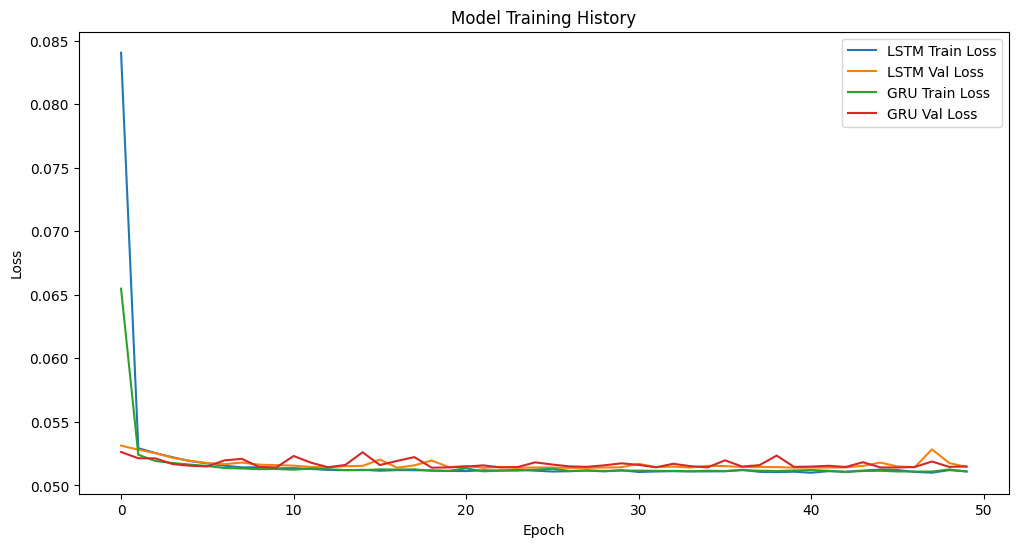

In [13]:
# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history_lstm.history['loss'], label='LSTM Train Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')
plt.plot(history_gru.history['loss'], label='GRU Train Loss')
plt.plot(history_gru.history['val_loss'], label='GRU Val Loss')
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# --- 1. PROSES UNTUK MODEL LSTM ---

# Kita perlu membuat array dummy karena scaler dilatih pada 5 fitur,
# sedangkan output kita hanya 1 fitur (PE).
# Kita tempatkan prediksi kita di kolom terakhir.
dummy_pred_lstm = np.zeros((len(y_pred_lstm), 5))
dummy_pred_lstm[:, -1] = y_pred_lstm.flatten()

# Lakukan inverse transform pada prediksi
y_pred_lstm_original = scaler.inverse_transform(dummy_pred_lstm)[:, -1]

# Lakukan juga inverse transform pada y_test agar satuannya sama
dummy_test = np.zeros((len(y_test), 5))
dummy_test[:, -1] = y_test.flatten()
y_test_original = scaler.inverse_transform(dummy_test)[:, -1]

# Hitung ulang metrik LSTM pada skala asli
rmse_lstm_original = np.sqrt(mean_squared_error(y_test_original, y_pred_lstm_original))
mse_lstm_original = mean_squared_error(y_test_original, y_pred_lstm_original)
mae_lstm_original = mean_absolute_error(y_test_original, y_pred_lstm_original)
r2_lstm_original = r2_score(y_test_original, y_pred_lstm_original)


# --- 2. PROSES UNTUK MODEL GRU ---

# Lakukan proses yang sama untuk prediksi dari GRU
dummy_pred_gru = np.zeros((len(y_pred_gru), 5))
dummy_pred_gru[:, -1] = y_pred_gru.flatten()
y_pred_gru_original = scaler.inverse_transform(dummy_pred_gru)[:, -1]

# Hitung ulang metrik GRU pada skala asli
rmse_gru_original = np.sqrt(mean_squared_error(y_test_original, y_pred_gru_original))
mse_gru_original = mean_squared_error(y_test_original, y_pred_gru_original)
mae_gru_original = mean_absolute_error(y_test_original, y_pred_gru_original)
r2_gru_original = r2_score(y_test_original, y_pred_gru_original)


# --- 3. TAMPILKAN HASIL AKHIR YANG SIAP DIMASUKKAN KE LAPORAN ---
print("="*50)
print("HASIL METRIK KINERJA (DALAM SKALA ASLI/MW)")
print("="*50)

print("\n--- Metode Kembangan (LSTM) ---")
print(f"R-squared (R²): {r2_lstm_original:.4f}")
print(f"RMSE: {rmse_lstm_original:.4f}")
print(f"MAE: {mae_lstm_original:.4f}")
print(f"MSE: {mse_lstm_original:.4f}")

print("\n--- Metode Kembangan (GRU) ---")
print(f"R-squared (R²): {r2_gru_original:.4f}")
print(f"RMSE: {rmse_gru_original:.4f}")
print(f"MAE: {mae_gru_original:.4f}")
print(f"MSE: {mse_gru_original:.4f}")
print("="*50)

HASIL METRIK KINERJA (DALAM SKALA ASLI/MW)

--- Metode Kembangan (LSTM) ---
R-squared (R²): -0.0043
RMSE: 17.1479
MAE: 14.9245
MSE: 294.0505

--- Metode Kembangan (GRU) ---
R-squared (R²): -0.0067
RMSE: 17.1686
MAE: 14.8814
MSE: 294.7612
